In [2]:
import re
import numpy as np
from typing import List, Tuple
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import textwrap
import pandas as pd

In [3]:
# 追加: COMMENT から SMILES/InChI を抜き出す正規表現
SMILES_RE = re.compile(r"\bsmiles\s*=\s*([^\s;]+)", re.IGNORECASE)
INCHI_RE  = re.compile(r"\bInChI\s*=\s*(InChI=[^\s;]+)", re.IGNORECASE)

def extract_block(record: str, tag: str) -> str:
    pattern = rf'<{tag}>\s*(.*?)\s*(?=(<[^>]+>|$))'
    m = re.search(pattern, record, re.DOTALL)
    return m.group(1).strip() if m else ''

def parse_peaks(block: str) -> List[Tuple[float, float]]:
    peaks = []
    for line in block.splitlines():
        parts = line.split()
        if len(parts) >= 2:
            try:
                mz = float(parts[0]); intensity = float(parts[1])
                peaks.append((mz, intensity))
            except ValueError:
                continue
    return peaks

def bin_peaks_to_vector(
    peaks: List[Tuple[float, float]],
    vector_size: int,
    bin_width: float = 1.0,
    weighted: bool = False,
    x: float = 1.0,
    y: float = 0.5
) -> np.ndarray:
    vec = np.zeros(vector_size, dtype=float)
    for mz, intensity in peaks:
        idx = int(mz // bin_width)
        if 0 <= idx < vector_size:
            vec[idx] += (mz**x)*(intensity**y) if weighted else intensity
    return vec

def cosine_similarity(
    vec1: np.ndarray,
    vec2: np.ndarray,
    normalize: bool = True
) -> float:
    if normalize:
        n1, n2 = np.linalg.norm(vec1), np.linalg.norm(vec2)
        if n1==0 or n2==0: return 0.0
        vec1, vec2 = vec1/n1, vec2/n2
    return float(np.dot(vec1, vec2))

def compute_similarity_vectors(
    meas_peaks, pred_peaks,
    bin_width: float = 1.0,
    weighted_params: Tuple[float, float] = (1.0, 0.5)
):
    max_mz = max((mz for mz,_ in meas_peaks+pred_peaks), default=0.0)
    size = int(max_mz//bin_width) + 1
    vec_simple_meas = bin_peaks_to_vector(meas_peaks, size, bin_width, False)
    vec_simple_pred = bin_peaks_to_vector(pred_peaks, size, bin_width, False)
    x, y = weighted_params
    vec_w_meas = bin_peaks_to_vector(meas_peaks, size, bin_width, True, x, y)
    vec_w_pred = bin_peaks_to_vector(pred_peaks, size, bin_width, True, x, y)
    return (
        vec_simple_meas,
        vec_simple_pred,
        cosine_similarity(vec_simple_meas, vec_simple_pred),
        cosine_similarity(vec_w_meas,    vec_w_pred)
    )

In [31]:
def main(
    bin_width: float = 1.0,
    weighted_params: Tuple[float, float] = (1.0, 0.5)
):
    sdf_path = '../data/MoNA_dedup_output.sdf'  # SDFファイルのパスを指定
    # SDF全レコード読み込み
    with open(sdf_path, 'r', encoding='utf-8') as f:
        content = f.read()
        records = [r for r in content.split('$$$$') if r.strip()]
    
    for idx, rec in enumerate(records, start=1):
        # 実測 vs 予測ピーク
        meas = parse_peaks(extract_block(rec, 'MASS SPECTRAL PEAKS'))
        pred = parse_peaks(extract_block(rec, 'PREDICTED SPECTRUM'))

        # COMMENT から SMILES/InChI を抽出
        comment = extract_block(rec, 'COMMENT')
        smi_match  = SMILES_RE.search(comment)
        inchi_match= INCHI_RE.search(comment)
        smiles = smi_match.group(1)    if smi_match   else 'N/A'
        inchi  = inchi_match.group(1)  if inchi_match else 'N/A'

        vec_m, vec_p, sim_s, sim_w = compute_similarity_vectors(
            meas, pred, bin_width, weighted_params
        )

    # smiles,cosine_sims,weighted_cosine_simsをカラムとするcsvを作成
        with open('../data/similarity_results_dedup.csv', 'a') as f:
            f.write(f"{smiles},{sim_s},{sim_w}\n")

if __name__ == "__main__":
    main(
        bin_width=1.0,
        weighted_params=(1.0, 0.5)
    )


=== 平均値 ===
similarity      0.754211
w_similarity    0.783106
dtype: float64

=== 分散 ===
similarity      0.021921
w_similarity    0.017644
dtype: float64


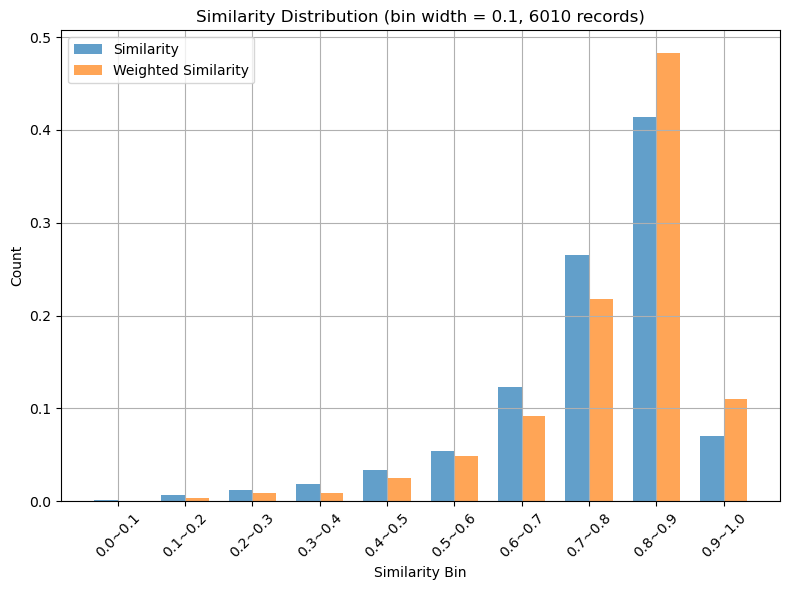

In [36]:
def similarity_stats():
    # CSVの読み込み
    df = pd.read_csv('../data/similarity_results_dedup.csv')

    # 平均と分散を計算
    mean_vals = df[['similarity', 'w_similarity']].mean()
    var_vals = df[['similarity', 'w_similarity']].var()

    # 結果を出力
    print("=== 平均値 ===")
    print(mean_vals)
    print("\n=== 分散 ===")
    print(var_vals)

def plot_histgram():
    # CSVの読み込み（ファイルパスを適宜変更してください）
    df = pd.read_csv('../data/similarity_results_dedup.csv')

    len_df = len(df)

    # ビンの定義（0.0-0.1, 0.1-0.2, ..., 0.9-1.0）
    bins = [i/10 for i in range(11)]
    labels = [f"{bins[i]:.1f}~{bins[i+1]:.1f}" for i in range(10)]

    # ビンに分割してカウント
    df['bin_1'] = pd.cut(df['similarity'], bins=bins, labels=labels, include_lowest=True, right=True)
    df['bin_2'] = pd.cut(df['w_similarity'], bins=bins, labels=labels, include_lowest=True, right=True)
    counts = df['bin_1'].value_counts().sort_index()
    w_counts = df['bin_2'].value_counts().sort_index()

    # カウント結果を表示
    # print("=== Similarity Bin Counts ===")
    # print(counts)
    # print("\n=== Weighted Similarity Bin Counts ===")
    # print(w_counts)

    counts_sum = counts.sum()
    w_counts_sum = w_counts.sum()

    rel_counts = counts / counts_sum if counts_sum > 0 else counts
    rel_w_counts = w_counts / w_counts_sum if w_counts_sum > 0 else w_counts 

    x = np.arange(len(labels))
    width = 0.35

    # 棒グラフの作成
    plt.figure(figsize=(8, 6), dpi=100)
    plt.bar(x - width/2, rel_counts.values, width, label='Similarity', alpha=0.7)
    plt.bar(x + width/2, rel_w_counts.values, width, label='Weighted Similarity', alpha=0.7)
    plt.xlabel('Similarity Bin')
    plt.ylabel('Count')
    plt.title(f'Similarity Distribution (bin width = 0.1, {len_df} records)')
    plt.xticks(x, labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid()
    plt.show()


similarity_stats()
plot_histgram()

In [40]:
# 各化合物についてフッ素の割合を計算
from rdkit import Chem

def calc_f_ratio(smi: str) -> float:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None  # 無効 SMILES は None を返して除外対象に
    # H (atomic num 1) を除く重原子数
    heavy_atoms = sum(1 for atom in mol.GetAtoms() if atom.GetAtomicNum() != 1)
    if heavy_atoms == 0:
        return 0.0
    # フッ素原子数 (atomic num 9)
    f_atoms = sum(1 for atom in mol.GetAtoms() if atom.GetAtomicNum() == 9)
    return f_atoms / heavy_atoms

df = pd.read_csv('../data/similarity_results_dedup.csv')
df['f_ratio'] = df['smiles'].apply(calc_f_ratio)

RATIO_THRESHOLD = 0.4
RATIO_PATH ='04'

# f_ratio > 0 の件数をカウント
f_ratio_positive_count = df[df['f_ratio'] > RATIO_THRESHOLD].shape[0]
print(f"フッ素の割合が{RATIO_THRESHOLD}より大きい化合物の件数: {f_ratio_positive_count}")

# # f_ratio > RATIO_THRESHOLD の化合物の構造式を表示
# f_ratio_positive_smiles = df[df['f_ratio'] > RATIO_THRESHOLD]['smiles'].tolist()
# print(f"フッ素の割合が{RATIO_THRESHOLD}より大きい化合物の SMILES:")
# for smi in f_ratio_positive_smiles:
#     mol = Chem.MolFromSmiles(smi)
#     if mol:
#         img = Chem.Draw.MolToImage(mol, size=(200, 200))
#         display(img)


# フッ素の割合が0.3以上の化合物のsimilarityとw_similarityの平均を計算
mean_s = df[df['f_ratio'] > RATIO_THRESHOLD]['similarity'].mean()
mean_w_s = df[df['f_ratio'] > RATIO_THRESHOLD]['w_similarity'].mean()
# print(f"フッ素の割合が{RATIO_THRESHOLD}以上の化合物のsimilarityの平均: {mean_s}")
# print(f"フッ素の割合が{RATIO_THRESHOLD}以上の化合物のw_similarityの平均: {mean_w_s}")

# フィルタリング
filtered = df[df['f_ratio'] > RATIO_THRESHOLD]

output_path = f'../data/stats/similarity_R{RATIO_PATH}_dedup.csv'

# 必要なカラムだけを抜き出して CSV に保存
filtered[['smiles', 'similarity', 'w_similarity']] \
    .to_csv(f'{output_path}', index=False, encoding='utf-8')

print(f"Filtered results saved to {output_path}")

フッ素の割合が0.4より大きい化合物の件数: 11
Filtered results saved to ../data/stats/similarity_R04_dedup.csv


Counts sum: 6010, Weighted counts sum: 6010
Fluoro counts sum: 103, Weighted Fluoro counts sum: 103


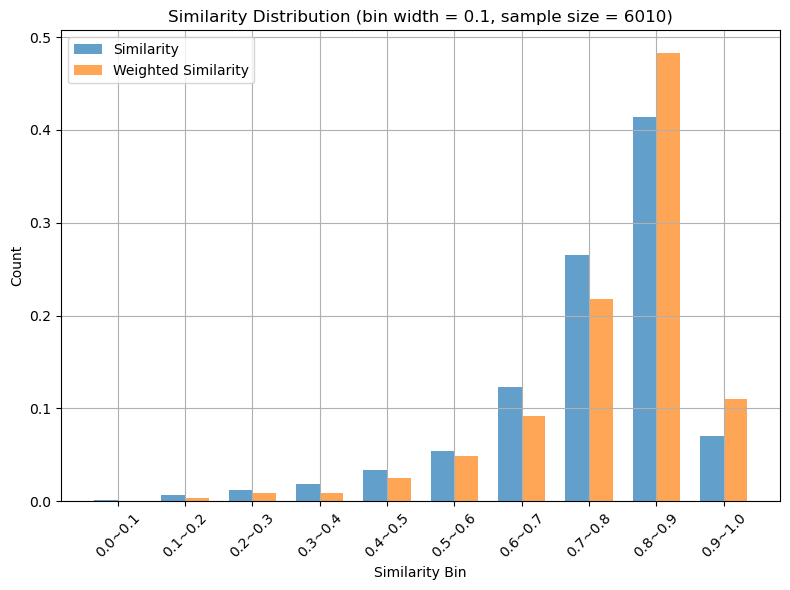

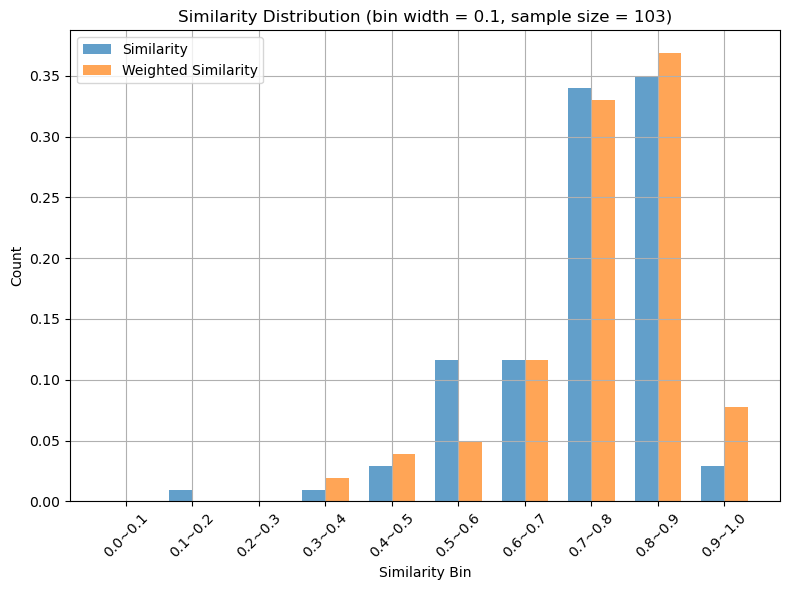

In [44]:
def plot_histgram_with_fluoro():
    RATIO_STR = '01'
    RATIO_THRESHOLD = '0.1'

    df_f = pd.read_csv(f'../data/stats/similarity_R{RATIO_STR}_dedup.csv')
    # CSVの読み込み（ファイルパスを適宜変更してください）
    df = pd.read_csv('../data/similarity_results_dedup.csv')

    # ビンの定義（0.0-0.1, 0.1-0.2, ..., 0.9-1.0）
    bins = [i/10 for i in range(11)]
    labels = [f"{bins[i]:.1f}~{bins[i+1]:.1f}" for i in range(10)]

    # ビンに分割してカウント
    df['bin_1'] = pd.cut(df['similarity'], bins=bins, labels=labels, include_lowest=True, right=True)
    df['bin_2'] = pd.cut(df['w_similarity'], bins=bins, labels=labels, include_lowest=True, right=True)
    df_f['bin_1'] = pd.cut(df_f['similarity'], bins=bins, labels=labels, include_lowest=True, right=True)
    df_f['bin_2'] = pd.cut(df_f['w_similarity'], bins=bins, labels=labels, include_lowest=True, right=True)
    counts = df['bin_1'].value_counts().sort_index()
    w_counts = df['bin_2'].value_counts().sort_index()
    f_counts = df_f['bin_1'].value_counts().sort_index()
    w_f_counts = df_f['bin_2'].value_counts().sort_index()

    # カウント結果を表示
    # print("=== Similarity Bin Counts ===")
    # print(counts)
    # print("\n=== Weighted Similarity Bin Counts ===")
    # print(w_counts)

    counts_sum = counts.sum()
    w_counts_sum = w_counts.sum()
    f_counts_sum = f_counts.sum()
    w_f_counts_sum = w_f_counts.sum()

    print(f"Counts sum: {counts_sum}, Weighted counts sum: {w_counts_sum}")
    print(f"Fluoro counts sum: {f_counts_sum}, Weighted Fluoro counts sum: {w_f_counts_sum}")

    rel_counts = counts / counts_sum if counts_sum > 0 else counts
    rel_w_counts = w_counts / w_counts_sum if w_counts_sum > 0 else w_counts 
    rel_f_counts = f_counts / f_counts_sum if f_counts_sum > 0 else f_counts
    rel_w_f_counts = w_f_counts / w_f_counts_sum if w_f_counts_sum > 0 else w_f_counts

    x = np.arange(len(labels))
    width = 0.35

    # 棒グラフの作成
    plt.figure(figsize=(8, 6), dpi=100)
    plt.bar(x - width/2, rel_counts.values, width, label='Similarity', alpha=0.7)
    plt.bar(x + width/2, rel_w_counts.values, width, label='Weighted Similarity', alpha=0.7)
    plt.xlabel('Similarity Bin')
    plt.ylabel('Count')
    plt.title(f'Similarity Distribution (bin width = 0.1, sample size = {counts_sum})')
    plt.xticks(x, labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid()
    plt.savefig(f'../data/stats/similarity_all_data.pdf', format='pdf')
    plt.show()

    plt.figure(figsize=(8, 6), dpi=100)
    plt.bar(x - width/2, rel_f_counts.values, width, label='Similarity', alpha=0.7)
    plt.bar(x + width/2, rel_w_f_counts.values, width, label='Weighted Similarity', alpha=0.7)
    plt.xlabel('Similarity Bin')
    plt.ylabel('Count')
    plt.title(f'Similarity Distribution (bin width = 0.1, sample size = {f_counts_sum})')
    plt.xticks(x, labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid()
    plt.savefig(f'../data/stats/similarity_fluoro_ratio_{RATIO_THRESHOLD}.pdf', format='pdf')
    plt.show()

plot_histgram_with_fluoro()

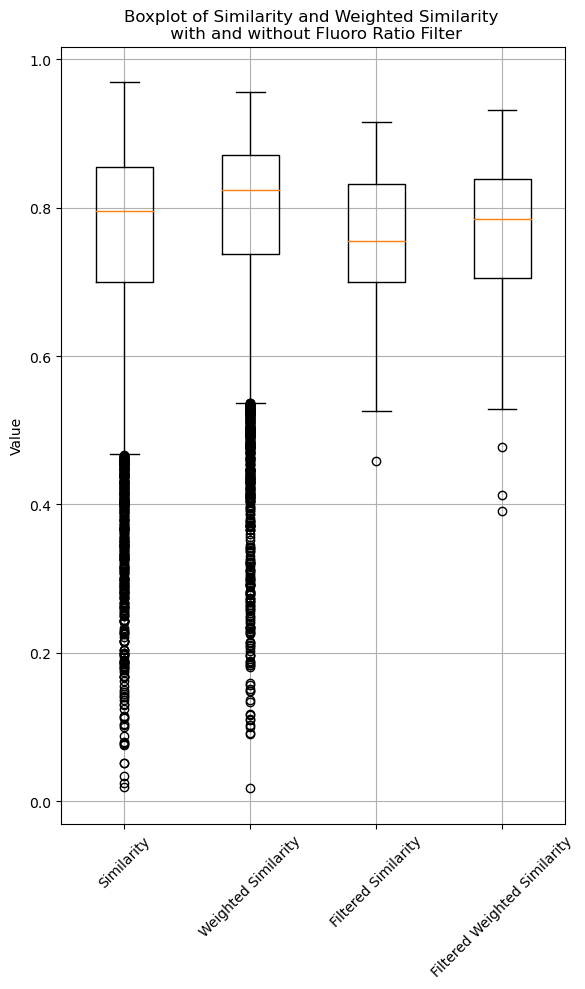

In [47]:
# CSVデータを読み込み
from io import StringIO

csv_data = pd.read_csv('../data/similarity_results_dedup.csv').to_csv(index=False)
csv_data_filtered = pd.read_csv('../data/stats/similarity_R02.csv').to_csv(index=False)

df = pd.read_csv(StringIO(csv_data))
df_filtered = pd.read_csv(StringIO(csv_data_filtered))

# 箱ひげ図を作成
plt.figure(figsize=(6, 10), dpi=100)
plt.boxplot([df['similarity'], df['w_similarity'], df_filtered['similarity'], df_filtered['w_similarity']],
            labels=['Similarity', 'Weighted Similarity', 'Filtered Similarity', 'Filtered Weighted Similarity'])
plt.xticks(rotation=45)
plt.title("Boxplot of Similarity and Weighted Similarity \
\n with and without Fluoro Ratio Filter")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.savefig('../data/stats/similarity_boxplot.pdf', format='pdf')
plt.show()

In [46]:
# アップロードされたCSVファイルの読み込み
# similarity と w_similarity の describe 統計を計算
uploaded_stats = {
    "Similarity": df['similarity'].describe(),
    "Weighted Similarity": df['w_similarity'].describe(),
    "Filtered Similarity": df_filtered['similarity'].describe(),
    "Filtered Weighted Similarity": df_filtered['w_similarity'].describe(),
}

# DataFrameとして表示
uploaded_stats_df = pd.DataFrame(uploaded_stats)
uploaded_stats_df


,Similarity,Weighted Similarity,Filtered Similarity,Filtered Weighted Similarity
count,6010.000000,6010.000000,67.000000,67.000000
mean,0.754211,0.783106,0.753144,0.759524
std,0.148058,0.132829,0.099572,0.121175
min,0.018663,0.017217,0.458256,0.391703
25%,0.699912,0.737797,0.699567,0.705163
50%,0.795724,0.823306,0.755700,0.784591
75%,0.854933,0.871606,0.831921,0.838121
max,0.969369,0.956353,0.914870,0.931679
